In [1]:
import pandas as pd
import numpy as np
from numpy import pi as π, sin, cos,log
import plotly.graph_objects as go

In [2]:
path_noise = "./Scores_Chen's_100.csv"
path_noiseless = "./Scores_entangled_100.csv"

df_noise = pd.read_csv(path_noise).sort_values(by=['Alpha_Coeff','States'])
df_noiseless = pd.read_csv(path_noiseless).sort_values(by=['Alpha_Coeff','States'])
font_family = "Arial"

In [27]:
def plotter(log_y_flag=True):
    # =========================================================
    # 1. Aggregate Data (Calculate mean and std dev)
    # =========================================================
    # Group by states for QST-based Noise
    df_noise_stats = df_noise.groupby("States")["R2_Score"].agg(["mean", "std"]).reset_index()
    #df_noise_stats = df_noise.groupby("States")["ε"].agg(["mean", "std"]).reset_index()
    #df_noise_stats = df_noise.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noise_stats["std"] = df_noise_stats["std"].fillna(0)
    
    # Group by states for Noiseless
    df_noiseless_stats = df_noiseless.groupby("States")["R2_Score"].agg(["mean", "std"]).reset_index()·
    #df_noiseless_stats = df_noiseless.groupby("States")["ε"].agg(["mean", "std"]).reset_index()
    #df_noiseless_stats["std"] = df_noiseless_stats["std"].fillna(0)

    # =========================================================
    # 2. Initialize Figure
    # =========================================================
    fig = go.Figure()

    opacity_value = 0.8
    
    # =========================================================
    # 3. Add Traces (Scatter plots with lines and error bars)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"],
        y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers',
        name="Mixed state",
        opacity=opacity_value,                 # Sets the overall opacity of the entire trace
        line=dict(
            dash='dash',             # Options: 'solid', 'dot', 'dash', 'longdash', etc.
            width=2),
        marker=dict(size=10)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"],
        y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers',
        name="Entangled state",
        opacity=opacity_value,                 # Sets the overall opacity of the entire trace
        line=dict(
            dash='dash',             # Options: 'solid', 'dot', 'dash', 'longdash', etc.
            width=2),
        marker=dict(size=10)
    ))

    # =========================================================
    # 4. Update Layout
    # =========================================================
    fig.update_layout(
        width=1000,
        height=563, # 16:9 Aspect Ratio
        plot_bgcolor='white',
        paper_bgcolor='white',
        
        # --- NEW LEGEND POSITIONING ---
        legend=dict(
            font=dict(family=font_family, size=12),
            yanchor="bottom",
            y=0.05,             # 5% from the bottom
            xanchor="right",
            x=0.95,             # 95% to the right
            bgcolor="rgba(255, 255, 255, 0.85)", # Semi-transparent white background
            bordercolor="lightgray",             # Optional border to frame it cleanly
            borderwidth=1
        ),
        
        xaxis=dict(
            title=dict(text="Number of states", font=dict(family=font_family, size=30)),
            tickfont=dict(family=font_family, size=12),
            showgrid=True, 
            gridwidth=1, 
            gridcolor='lightgray', 
            zeroline=False
        ),
        
        yaxis=dict(
            title=dict(text="ϵ", font=dict(family=font_family, size=30)),
            tickfont=dict(family=font_family, size=12),
            showgrid=True, 
            gridwidth=1, 
            gridcolor='lightgray', 
            zeroline=False,
            type='log' if log_y_flag else 'linear'
        )
    )

    # =========================================================
    # 5. Export and Display
    # =========================================================
    output_html = "RMSE_Analysis_Combined_ErrorBars.html"
    #fig.write_html(output_html)
    print(f"Combined error bar plot generated and saved to: {output_html}")
    
    fig.show()

SyntaxError: invalid character '·' (U+00B7) (185030959.py, line 12)

In [28]:
df_noise.keys()

Index(['Filename', 'Alpha_Coeff', 'Alpha_Label', 'Pt', 'States', 'Rows',
       'Cols', 'R2_Score', 'RMSE', 'ε'],
      dtype='object')

Combined error bar plot generated and saved to: RMSE_Analysis_Combined_ErrorBars.html


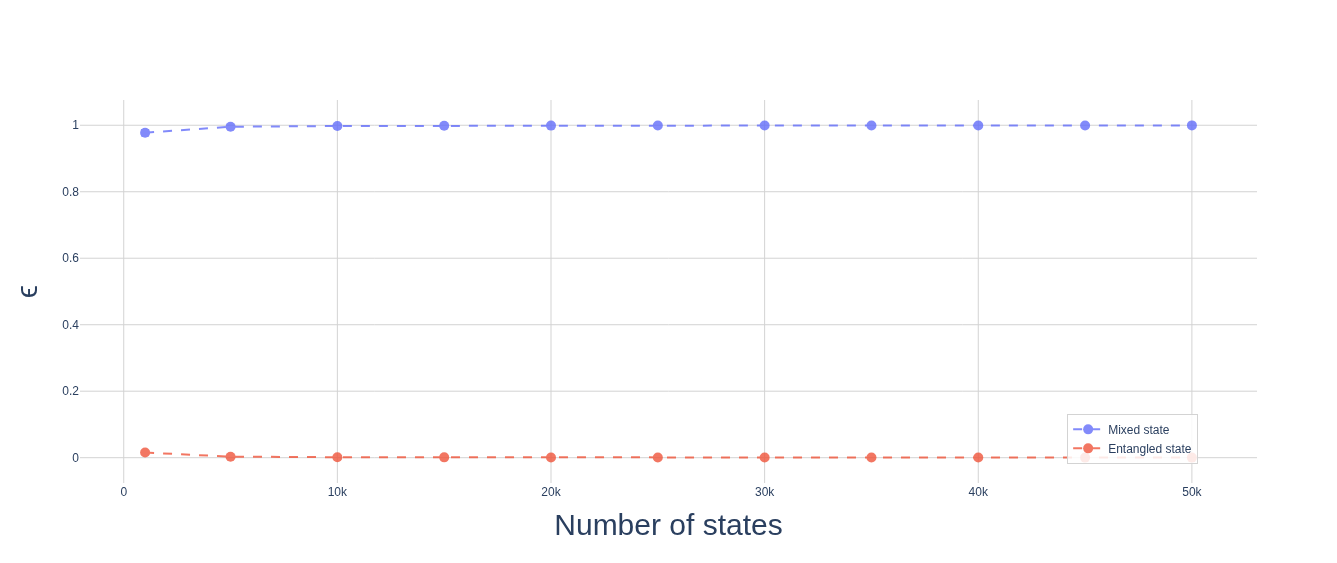

Combined error bar plot generated and saved to: RMSE_Analysis_Combined_ErrorBars.html


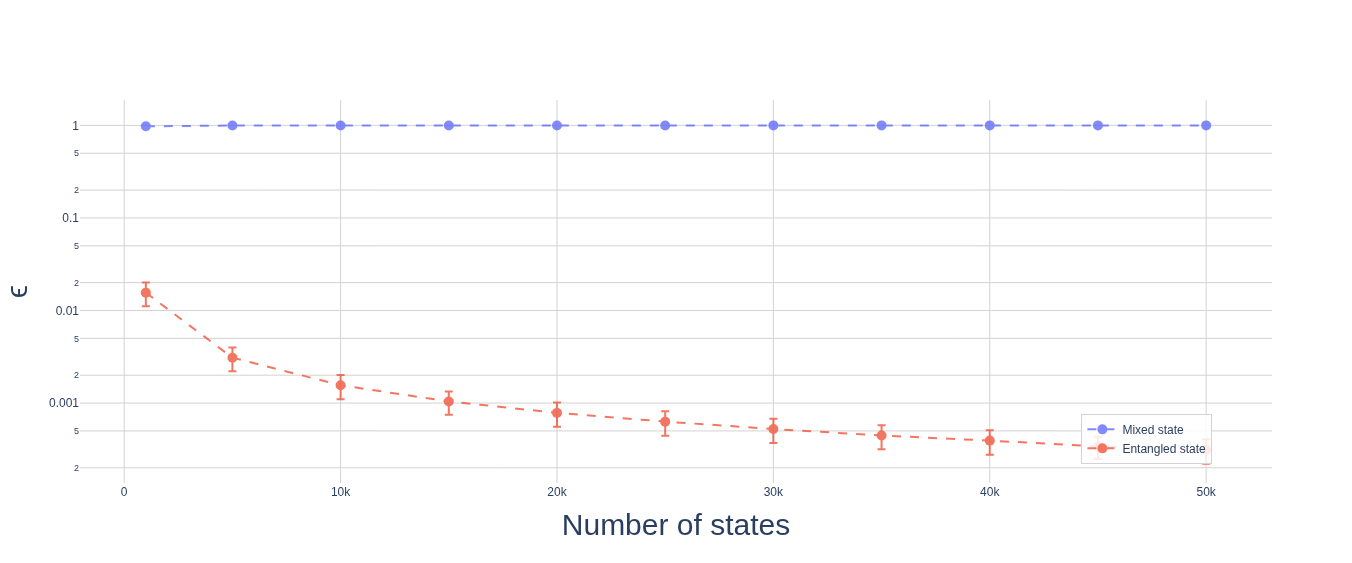

[None, None]

In [29]:
display([plotter(log_y_flag=False),plotter(log_y_flag=True)])

In [102]:
def plotter_inset():
    # =========================================================
    # 1. Aggregate Data (Calculate mean and std dev)
    # =========================================================
    df_noise_stats = df_noise.groupby("States")["ε"].agg(["mean", "std"]).reset_index()
    #df_noise_stats = df_noise.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noise_stats["std"] = df_noise_stats["std"].fillna(0)
    
    df_noiseless_stats = df_noiseless.groupby("States")["ε"].agg(["mean", "std"]).reset_index()
    #df_noiseless_stats = df_noiseless.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noiseless_stats["std"] = df_noiseless_stats["std"].fillna(0)

    color_noise = '#636EFA'
    color_noiseless = '#EF553B'

    # =========================================================
    # 2. Initialize Figure & Variables
    # =========================================================
    fig = go.Figure()
    opacity_value = 0.8

    # =========================================================
    # 3. Add MAIN Traces (Linear scale)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"], y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers', name="Mixed state",
        marker=dict(size=10, color=color_noise), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noise)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"], y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers', name="Entangled state",
        marker=dict(size=10, color=color_noiseless), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noiseless)
    ))

    # =========================================================
    # 4. Add INSET Traces (Mapped to x2, y2)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"], y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers', showlegend=False,
        xaxis='x2', yaxis='y2', 
        marker=dict(size=10, color=color_noise), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noise)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"], y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers', showlegend=False,
        xaxis='x2', yaxis='y2', 
        marker=dict(size=10, color=color_noiseless), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noiseless)
    ))

    # =========================================================
    # 5. Update Layout (Main Axes, Inset Axes, Fonts, Sizes)
    # =========================================================
    
    min_inset, max_inset = [2.1e-4,1.1e-3]
    
    fig.update_layout(
        width=750,
        height=500, 
        plot_bgcolor='white',
        paper_bgcolor='white',
        
        legend=dict(
            font=dict(family=font_family, size=12)
        ),
        
        # --- MAIN X-Axis ---
        xaxis=dict(
            title=dict(text="Number of states (N)", font=dict(family=font_family, size=12)), 
            tickfont=dict(family=font_family, size=12), 
            showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=False,
            showline=True, linewidth=1, linecolor='gray', mirror=True
        ),
        
        # --- MAIN Y-Axis ---
        yaxis=dict(
            title=dict(text="ϵ", font=dict(family=font_family, size=12)), 
            tickfont=dict(family=font_family, size=12),
            showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=False,
            type='linear',
            showline=True, linewidth=1, linecolor='gray', mirror=True
        ),

        # --- INSET X-Axis (x2) ---
        xaxis2=dict(
            domain=[0.33, 0.95], 
            anchor='y2',
            range=[29000, 51000], 
            # Increased font size to 20
            tickfont=dict(family=font_family, size=12),
            showgrid=True, gridcolor='lightgray',
            # Increased font size to 20
            title=dict(text="Zoom (30k-50k)", font=dict(family=font_family, size=12)),
            showline=True, linewidth=1, linecolor='gray', mirror=True 
        ),
        
        # --- INSET Y-Axis (y2) ---
        yaxis2=dict(
            domain=[0.4, 0.96],  
            anchor='x2',
            type='linear',
            #range=[np.log10(min_inset),np.log10(max_inset)], 
            range=[(min_inset),(max_inset)], 
            # Explicitly declare which ticks to show to prevent crowding
            tickvals=[0.0002, 0.0003, 0.0005, 0.0007, 0.0009],
            #tickvals=np.linspace(min_inset,max_inset,5,dtype=np.float32),
            # Increased font size to 20
            tickfont=dict(family=font_family, size=12),
            showgrid=True, gridcolor='lightgray',
            showline=True, linewidth=1, linecolor='gray', mirror=True
        )
    )

    # =========================================================
    # 6. Export and Display
    # =========================================================
    output_html = "R2_Analysis_Inset_Framed_TicksFixed.html"
    output_vector = "RMSE_convergence.pdf"
    #fig.write_image(output_vector)
    print(f"Plot with framed inset generated and saved to: {output_html}")
    
    fig.show()
    fig.write_image("Convergence_epsilon.pdf")

Plot with framed inset generated and saved to: R2_Analysis_Inset_Framed_TicksFixed.html


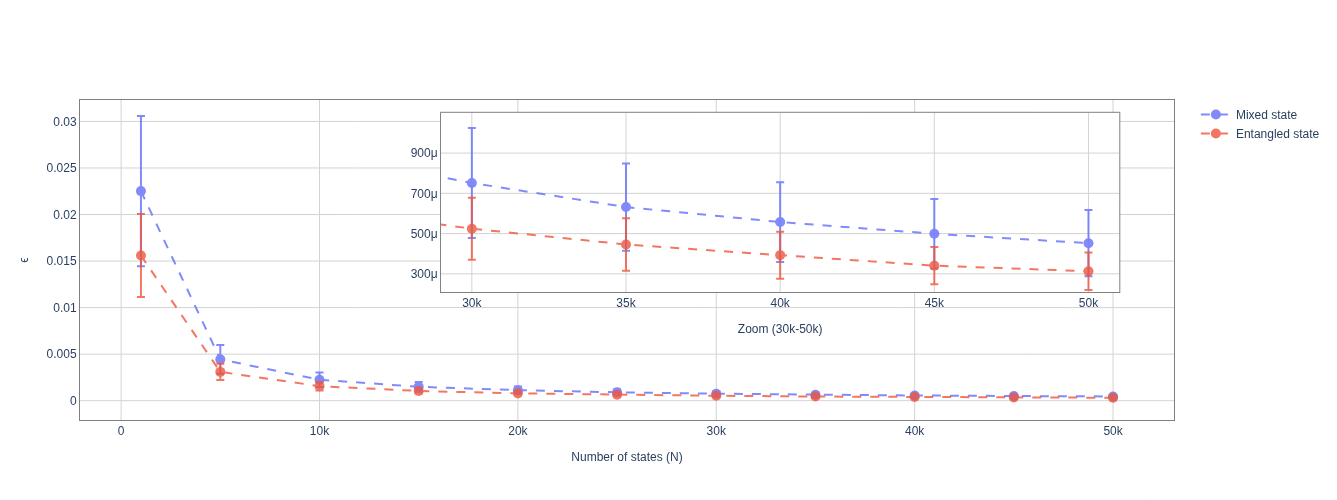

/tmp/ipykernel_80250/2999439780.py:138: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [103]:
plotter_inset()

In [93]:
min_inset, max_inset = [2.1e-4,1.1e-3]
np.round(np.linspace(min_inset,max_inset,5,dtype=np.float32)*1e4)*1e-4

array([0.0002, 0.0004, 0.0007, 0.0009, 0.0011], dtype=float32)

# PLOS one plots

In [ ]:
def plotter_plos(df_noise, df_noiseless):
    # =========================================================
    # 1. Aggregate Data (Calculate mean and std dev)
    # =========================================================
    df_noise_stats = df_noise.groupby("States")["ε"].agg(["mean", "std"]).reset_index()
    df_noise_stats["std"] = df_noise_stats["std"].fillna(0)
    
    df_noiseless_stats = df_noiseless.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noiseless_stats["std"] = df_noiseless_stats["std"].fillna(0)

    # Standard high-contrast distinct colors
    color_noise = '#636EFA'
    color_noiseless = '#EF553B'

    # =========================================================
    # 2. Initialize Figure 
    # =========================================================
    fig = go.Figure()
    
    # NOTE: PLOS ONE discourages transparent elements in TIFF/EPS exports.
    # Opacity removed (defaults to 1.0) to avoid flattening artifacts.

    # =========================================================
    # 3. Add MAIN Traces (Linear scale)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"], y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers', name="Mixed state",
        marker=dict(size=8, color=color_noise), # Size matched to new scale
        line=dict(dash='dash', width=1.5, color=color_noise)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"], y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers', name="Entangled state",
        marker=dict(size=8, color=color_noiseless), 
        line=dict(dash='dash', width=1.5, color=color_noiseless)
    ))

    # =========================================================
    # 4. Add INSET Traces (Mapped to x2, y2)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"], y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers', showlegend=False,
        xaxis='x2', yaxis='y2', 
        marker=dict(size=6, color=color_noise), # Smaller markers for inset
        line=dict(dash='dash', width=1.5, color=color_noise)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"], y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers', showlegend=False,
        xaxis='x2', yaxis='y2', 
        marker=dict(size=6, color=color_noiseless), 
        line=dict(dash='dash', width=1.5, color=color_noiseless)
    ))

    # =========================================================
    # 5. Update Layout (PLOS ONE Formatting)
    # =========================================================
    # PLOS ONE Guidelines Compliance:
    # - Fonts: Arial, Times, or Symbol. Sized 8-12pt.
    # - Grids/Background: Clean backgrounds, gridlines hidden.
    # - Borders/Axes: Solid black lines (min 0.5pt width).
    
    font_family = "Arial"
    
    fig.update_layout(
        width=750,  
        height=500, 
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=60, r=20, t=20, b=50), # Clean, tight margins
        
        legend=dict(
            font=dict(family=font_family, size=10),
            x=0.05, y=0.95,
            xanchor='left', yanchor='top',
            bgcolor='white',
            bordercolor='black',
            borderwidth=1
        ),
        
        # --- MAIN X-Axis ---
        xaxis=dict(
            title=dict(text="Number of states (N)", font=dict(family=font_family, size=12)), 
            tickfont=dict(family=font_family, size=10), 
            showgrid=False, zeroline=False,
            showline=True, linewidth=1, linecolor='black', mirror=True,
            ticks='outside', tickcolor='black', tickwidth=1
        ),
        
        # --- MAIN Y-Axis ---
        yaxis=dict(
            title=dict(text="ϵ", font=dict(family=font_family, size=12)), 
            tickfont=dict(family=font_family, size=10),
            showgrid=False, zeroline=False, type='linear',
            showline=True, linewidth=1, linecolor='black', mirror=True,
            ticks='outside', tickcolor='black', tickwidth=1
        ),

        # --- INSET X-Axis (x2) ---
        xaxis2=dict(
            domain=[0.45, 0.95], # Shifted slightly so inset won't overlap legend
            anchor='y2',
            range=[29000, 51000], 
            tickfont=dict(family=font_family, size=10),
            title=dict(text="Zoom (30k-50k)", font=dict(family=font_family, size=10)),
            showgrid=False, zeroline=False,
            showline=True, linewidth=1, linecolor='black', mirror=True,
            ticks='inside', tickcolor='black', tickwidth=1
        ),
        
        # --- INSET Y-Axis (y2) ---
        yaxis2=dict(
            domain=[0.45, 0.90],  
            anchor='x2',
            type='log',
            range=[np.log10(2.9e-3), np.log10(5.1e-3)], 
            tickvals=[0.003, 0.004, 0.005], # Reduced crowding for 10pt fonts
            tickfont=dict(family=font_family, size=10),
            showgrid=False, zeroline=False,
            showline=True, linewidth=1, linecolor='black', mirror=True,
            ticks='inside', tickcolor='black', tickwidth=1
        )
    )
    fig.show()

In [ ]:
plotter_plos(df_noise = pd.read_csv(path_noise).sort_values(by=['Alpha_Coeff','States']),df_noiseless = pd.read_csv(path_noiseless).sort_values(by=['Alpha_Coeff','States']))

# TEST surf plot

In [ ]:
experiment_noiseless = pd.read_csv('./noiseless simulation/100/alpha_1.00pi_Pt_1.0000_100x100_mesh_5.0E+04_states_SIM_25_05_2026_14_37_44.csv',header=None).dropna(axis=1,how='all').values
experiment_noisy = pd.read_csv('./Chen_based_sims/100/gpu_alpha_1.00pi_Pt_0.9107_100x100_mesh_5.0E+04_states_SIM_25_05_2026_14_42_44.csv',header=None).dropna(axis=1,how='all').values
dim = len(experiment_noiseless)

θ = np.linspace(0, 2*np.pi, dim)
β = np.linspace(0, np.pi, dim)

# Pre-calcular ambos modelos para mantener el gráfico limpio
#model = np.array([[model_noise(theta, np.pi/16, beta, Pt=(68/100)) for beta in β] for theta in θ])
#model_pure = np.array([[model_noise(theta, np.pi/16, beta, Pt=(1)) for beta in β] for theta in θ])

fig = go.Figure()

# --- Grupo de 30% Error (Colores Cálidos, sin blanco) ---
fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = experiment_noisy, 
    colorscale='Inferno',  # Cálido, oscuro a brillante (sin blanco)
    opacity=0.95,          # Opacidad alta para datos sólidos
    name='Noisy Experiment',
    colorbar=dict(
        title=dict(text='Exp. 50K states', font=dict(size=13)), 
        x=1.02, 
        thickness=15
    )
))

fig.add_trace(go.Surface(
    x = β,
    y = θ,
    z = experiment_noiseless, 
    colorscale='Solar',    # Rojos/Naranjas sólidos (sin blanco)
    opacity=0.45,          # Translúcido para ver el experimento a través
    name='Noisy Model',
    colorbar=dict(
        title=dict(text='Exp. 50K states', font=dict(size=13)), 
        x=1.12, 
        thickness=15
    )
))

# Customize the layout
fig.update_layout(
    title=dict(
        #text=f"Noisy Experiment correlation <br>R<sup>2</sup>={r2(y_true=model,y_pred=experiment_noisy):1.4f}",
        x = 0.5,
        font=dict(size=24)
    ),
    autosize=False,
    width=1100, 
    height=800,
    margin=dict(l=65, r=60, b=65, t=90),
    scene=dict(
        xaxis=dict(
            title='β',
            tickmode='array',
            tickvals=[0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
            ticktext=['0', 'π/4', 'π/2', '3π/4', 'π']
        ),
        yaxis=dict(
            title='θ',
            tickmode='array',
            tickvals=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
            ticktext=['0', 'π/2', 'π', '3π/2', '2π']
        ),
        zaxis_title='Probability',
        zaxis=dict(range=[0,1])
    ),
    font=dict(size=16)
)

fig.show()